In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage as ski
import bm3d
import tifffile as tiff

# Paths
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.append(project_root)

import modules.optics as op
from BioTISR.read_mrc import read_mrc

# Set plotting styles
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 12

0.0 1.0 (180, 512, 512)


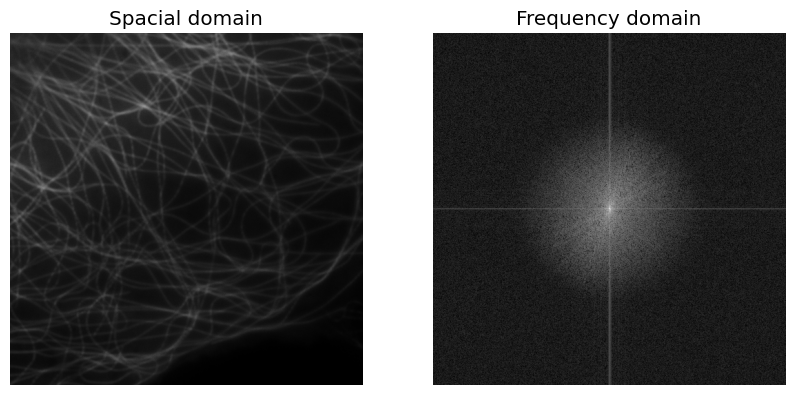

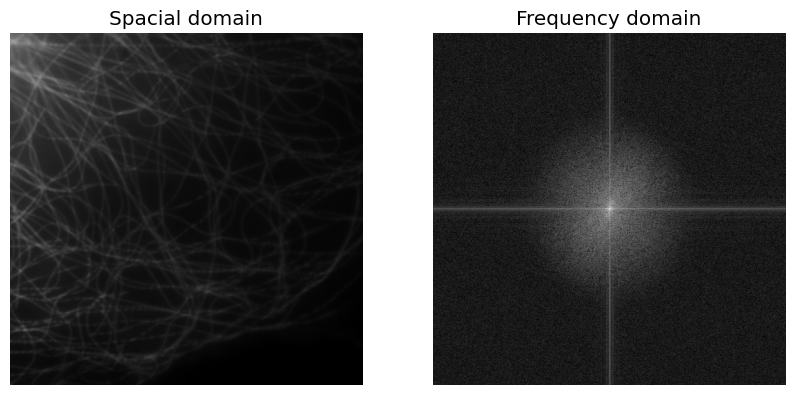

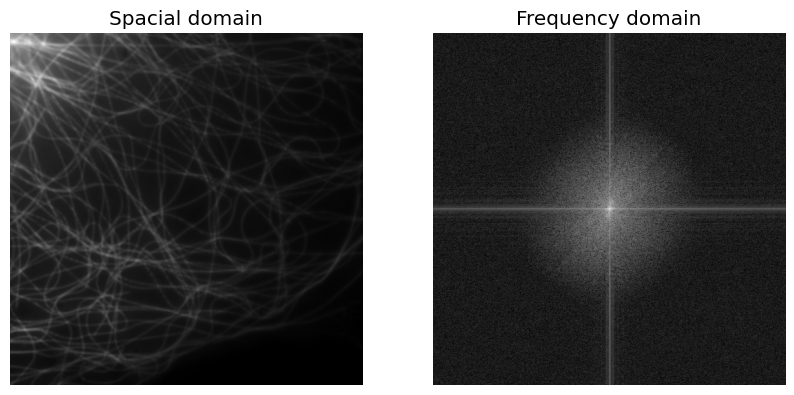

In [9]:
folder_path = '../../BioTISR/BioTISR_Microtubules/Cell_001/'
header, data = read_mrc(os.path.join(folder_path, 'RawSIMData_level_03.mrc'))
data[data < 0] = 0
data = op.normalize(data)
data = data.transpose(2, 0, 1)
data = np.rot90(data, k=1, axes=(1, 2))

data_shape = np.shape(data)
print(np.min(data), np.max(data), data_shape)
op.display_fourier(data[0])
op.display_fourier(data[3])
op.display_fourier(data[6])


In [4]:
# Wiener filter
psf = op.gaussian_psf(3)
wiener_raw = np.zeros(data_shape)

balance = 0.00001 # 1% 0.0001

for i in range(data_shape[0]):
    wiener_raw[i] = ski.restoration.wiener(data[i], psf, balance)

In [5]:
# Total variation filter
tv_raw = np.zeros(data_shape)

weight = 0.0000001 # 1% 0.0002
for i in range(data_shape[0]):
    tv_raw[i] = ski.restoration.denoise_tv_chambolle(data[i], weight)

In [6]:
# BM3D filter
bm3d_raw = np.zeros(data_shape)
sigma_psd = 0.0001 # 1% 0.001
for i in range(data_shape[0]):
    bm3d_raw[i] = bm3d.bm3d(data[i], sigma_psd, stage_arg=bm3d.BM3DStages.HARD_THRESHOLDING)

In [7]:
# Richardson-Lucy filter
rl_raw = np.zeros(data_shape)
psf = op.gaussian_psf(3)

for i in range(data_shape[0]):
    rl_raw[i] = ski.restoration.richardson_lucy(data[i], psf, num_iter=30)

In [8]:
# Save all data
save = 1
if save:
    filtered_raw = np.stack([data, wiener_raw, tv_raw, bm3d_raw, rl_raw])
    ski.io.imsave(os.path.join(folder_path, 'filtered_raw.tif'), filtered_raw)